#### Projet: Création d'un modèle d'apprentissage automatique
****Le but :**** prédire si un client est généreux en pourboires ou non.

##### *Approche pour construire le modele:*

**Etape 1 :** Considérations éthiques

* Examinez les implications éthiques de la demande.

* L’objectif du modèle doit-il être ajusté ?

**Etape 2 :** Ingénierie des caractéristiques

* Effectuez la sélection, l’extraction et la transformation des caractéristiques afin de préparer les données pour la modélisation.

**Etape 3 :** Modélisation

* Construisez les modèles, évaluez-les et proposez des pistes pour les prochaines étapes.

#### ** 1. Importations et chargement des données**
Importer les packages et bibliothèques nécessaires à la construction et à l'évaluation des modèles de classification `Random Forest` et `XGBoost`.

In [228]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Cette fonction permettra de representer graphiquement l'importance des variables
from xgboost import plot_importance

In [229]:
# Ceci permet d'afficher toutes les colonnes, évitant ainsi que Jupyter ne les masque.

pd.set_option('display.max_columns', None)

A present l'on charger les données. Il y a deux dataframes : l'un contient les données originales, l'autre les durées moyennes, les distances moyennes et les tarifs estimés du projet du cours précédent, nommé nyc_preds_means.csv.

In [230]:
# Charger le jeu de données dans un dataframe df0
df0=pd.read_csv('ag_motos_tricycles.csv')

# Importer les tarifs prédits, la distance moyenne et la durée des trajets du projet précédent
nyc_preds_means=pd.read_csv('nyc_preds_means.csv')


In [231]:
# Inspecter les premières lignes de df0
df0.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [232]:
# Inspecter les premières lignes de `nyc_preds_means`
nyc_preds_means.head()

,mean_duration,mean_distance,predicted_fare
0,22.848333,3.521667,16.171913
1,24.470000,3.108889,17.116947
2,7.250286,0.881429,6.346027
3,30.250000,3.700000,18.361804
4,14.620000,4.435000,15.681980


#### Fusionner les deux dataframes

Fusionner les deux dataframes à l'aide de la méthode de votre choix.

In [233]:
# L'on va utiliser 'join' pour fusionner les deux dataframes

df0=df0.join(nyc_preds_means)   
df0.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,22.848333,3.521667,16.171913
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,24.470000,3.108889,17.116947
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.250286,0.881429,6.346027
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,3.700000,18.361804
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,14.620000,4.435000,15.681980


### **2. Ingénierie des caractéristiques**

Une grande partie de ces données a été préparé et une analyse exploratoire des données (AED) effectueé lors du pjojet precendent.

L'on va simplement appeler la fonction `info()` sur le dataframe.

In [234]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

L'on sait déjà grâce à l'AED effectuée, que les clients qui paient en espèces laissent généralement un pourboire de 0 $. 

Dans ce cas pour atteindre l’objectif de modélisation, il va falloir échantillonner les données afin de ne sélectionner que les clients qui paient par carte bancaire.

Copie de `df0` et assignation du résultat à une variable `df1`. Ensuite, utiliser un masque booléen pour filtrer `df1` afin qu'elle ne contienne que les clients ayant payé par carte bancaire.

In [235]:
# Filtrer les données pour isoler uniquement les clients ayant payé par carte bancaire
df1 = df0[df0['payment_type']==1].copy()

##### **Cible**

L'absence d'une colonne indiquant le pourcentage de pourboire est remarquable, information pourtant nécessaire à la création de la variable cible. 

Il faut donc créer et ajouter la colonne `tip_percent`au dataframe.

$$tip\ percent = \frac{tip\ amount}{total\ amount - tip\ amount}$$

Arrondir le résultat à trois décimales. **Cette étape est importante.** Elle détermine le nombre de clients considérés comme généreux en pourboires. En fait, sans cette étape, environ 1 800 personnes qui laissent un pourboire d'au moins 20 % seraient considérées comme peu généreuses.

Pour comprendre pourquoi, il faut s'intéresser au fonctionnement des nombres à virgule flottante. Les ordinateurs effectuent leurs calculs grâce à l'arithmétique à virgule flottante (d'où le terme « flottant »). Ce système permet aux ordinateurs d'exprimer avec une grande précision aussi bien les très grands nombres que les très petits, sous forme binaire. Cependant, la précision est limitée par le nombre de bits utilisés pour représenter un nombre, généralement 32 ou 64, selon les capacités du système d'exploitation.

Cela présente des limitations : il arrive que des calculs qui devraient donner des valeurs précises soient encodés sous forme de très longs nombres décimaux. Prenons l'exemple du calcul suivant :

In [236]:
# Créer la colonne « Pourcentage de pourboire »
df1['tip_percent'] = (df1['tip_amount'] / (df1['total_amount'] - df1['tip_amount'])).round(3)

L'on va créer maintenant une autre colonne appelée `generous`. Ce sera la variable cible. La colonne doit être un indicateur binaire indiquant si un client a laissé un pourboire ≥ 20 % (0 = non, 1 = oui).

1. L'on va copier la colonne `tip_percent` dans la colonne `generous`.

2. Ensuite convertir la colonne en booléen (Vrai/Faux).

3. Enfin convertir la colonne en binaire (1/0).

In [237]:
# Créer la colonne « generous » (cible)
df1['generous'] = df1['tip_percent']
df1['generous'] = (df1['generous'] >= 0.2)
df1['generous'] = df1['generous'].astype('int64')

<details>
  <summary><h5>CONVERT</h5></summary>

To convert from Boolean to binary, use `.astype(int)` on the column.
</details>

##### Créer la colonne « DAY »

Ensuite, l'on va travailler avec les colonnes « pickup » et « dropoff ».

Convertir les colonnes `tpep_pickup_datetime` et `tpep_dropoff_datetime` au format datetime.

In [238]:
# Convertir les colonnes de depart et d'arrivee  au format datetime
df1['tpep_pickup_datetime'] = pd.to_datetime(df1['tpep_pickup_datetime'], format='%m/%d/%Y %I:%M:%S %p')
df1['tpep_dropoff_datetime'] = pd.to_datetime(df1['tpep_dropoff_datetime'], format='%m/%d/%Y %I:%M:%S %p')

*****Créer une colonne `day` contenant uniquement le jour de la semaine de prise en charge de chaque passager. Convertir ensuite les valeurs en minuscules.*****

In [239]:
df1['day']=df1['tpep_pickup_datetime'].dt.day_name().str.lower()

#### Créer une colonne `hour`

A partir de celle ci créer quatre nouvelles colonnes représentant les plages horaires. Chaque colonne doit contenir des valeurs binaires (0 = non, 1 = oui) indiquant si une course a commencé (pris en charge) pendant les périodes suivantes :

`am_rush` = [06:00–10:00)

`daytime` = [10:00–16:00)

`pm_rush` = [16:00–20:00)

`nighttime` = [20:00–06:00)

Pour ce faire, commencez par créer les quatre colonnes. Dans un premier temps, chaque nouvelle colonne doit être identique et contenir la même information : l’heure (uniquement) de la colonne `tpep_pickup_datetime`.

In [240]:
# Creer la colonne 'hour'
df1['hour']=df1['tpep_pickup_datetime'].dt.hour

In [241]:
# Creer la colonne 'am_rush'
df1['am_rush'] = df1['hour'].between(6,9).astype('int64')

# Creer la colonne 'daytime'
df1['daytime'] = df1['hour'].between(10,15).astype('int64')

# Creer la conne 'pm_rush'
df1['pm_rush'] = df1['hour'].between(16,19).astype('int64')

# Creer la colonne 'nighttime'
df1['nighttime']=((df1['hour'].between(20,24))|(df1['hour'].between(1,5))).astype('int64')

In [242]:
# Creer la colonne'month'
df1['month']=df1['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

In [243]:
#Examiner les 5 premieres lignes
df1.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare,tip_percent,generous,day,hour,am_rush,daytime,pm_rush,nighttime,month
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,22.848333,3.521667,16.171913,0.200,1,saturday,8,1,0,0,0,mar
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,24.470000,3.108889,17.116947,0.238,1,tuesday,14,0,1,0,0,apr
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.250286,0.881429,6.346027,0.199,0,friday,7,1,0,0,0,dec
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,3.700000,18.361804,0.300,1,sunday,13,0,1,0,0,may
5,23345809,2,2017-03-25 20:34:11,2017-03-25 20:42:11,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36,11.855484,2.052258,11.038190,0.200,1,saturday,20,0,0,0,1,mar


#### Suppression des colonnes non pertinentes

Supprimez les colonnes redondantes et non pertinentes, ainsi que celles qui ne seront pas disponibles lors du déploiement du modèle. Cela inclut des informations telles que le type de paiement, la distance du trajet, le montant du pourboire, le pourcentage du pourboire, le montant total, le montant du péage, etc. 

**NB:** La variable cible (`« generous »`) doit être conservée dans les données car elle sera isolée.

In [244]:
# Suppression des colonnes
drop_cols = ['Unnamed: 0', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
             'payment_type', 'trip_distance', 'store_and_fwd_flag', 'payment_type',
             'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
             'improvement_surcharge', 'total_amount', 'tip_percent', 'hour']
df1=df1.drop(drop_cols, axis=1)
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15265 entries, 0 to 22698
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         15265 non-null  int64  
 1   passenger_count  15265 non-null  int64  
 2   RatecodeID       15265 non-null  int64  
 3   PULocationID     15265 non-null  int64  
 4   DOLocationID     15265 non-null  int64  
 5   mean_duration    15265 non-null  float64
 6   mean_distance    15265 non-null  float64
 7   predicted_fare   15265 non-null  float64
 8   generous         15265 non-null  int64  
 9   day              15265 non-null  object 
 10  am_rush          15265 non-null  int64  
 11  daytime          15265 non-null  int64  
 12  pm_rush          15265 non-null  int64  
 13  nighttime        15265 non-null  int64  
 14  month            15265 non-null  object 
dtypes: float64(3), int64(10), object(2)
memory usage: 1.7+ MB


#### Encodage des variables

De nombreuses colonnes sont catégorielles et devront être transformées en variables binaires. Certaines de ces colonnes sont numériques, mais elles contiennent en réalité des informations catégorielles, comme `RatecodeID` et les lieux de prise en charge et de dépose. Pour que la fonction `get_dummies()` puisse les interpréter comme des variables catégorielles, vous devez d'abord les convertir au format `type(str)`.

1. Définir une variable appelée `cols_to_str`, qui est une liste des colonnes numériques contenant des informations catégorielles et qui doivent être converties en chaînes de caractères : `RatecodeID`, `PULocationID`, `DOLocationID`.

2. Écrire une boucle `for` qui convertit chaque colonne de `cols_to_str` en chaîne de caractères.


In [245]:
# 1. Définir la liste des colonnes à convertir en chaîne de caractères :

cols_to_str = ['RatecodeID', 'PULocationID', 'DOLocationID', 'VendorID']

# 2. Convertir chaque colonne en chaîne de caractères :

for col in cols_to_str:
    df1[col] = df1[col].astype('str')

Convertir maintenant toutes les colonnes catégorielles en binaire.

1. Appeler la fonction `get_dummies()` sur le dataframe et assignez les résultats à un nouveau dataframe appelé `df2`.

In [246]:
# Convertir les variables catégorielles en binaires

df2 = pd.get_dummies(df1, drop_first=True)

df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15265 entries, 0 to 22698
Columns: 347 entries, passenger_count to month_sep
dtypes: bool(338), float64(3), int64(6)
memory usage: 6.1 MB


#### Métrique d'évaluation

Avant de modéliser, il faut définir une métrique d'évaluation.

1. Examiner l'équilibre des classes de votre variable cible.

In [247]:
# Obtenir l'équilibre des classes de la colonne « généreux »
df2['generous'].value_counts(normalize=True)

generous
1    0.526368
0    0.473632
Name: proportion, dtype: float64

**Remarque :** Un peu plus de la moitié des clients de cet ensemble de données étaient « généreux » (pourboire ≥ 20 %). L'ensemble de données est quasiment équilibré.

Pour définir une métrique, tenez compte du coût des deux types d'erreurs de modélisation :

* Faux positifs (le modèle prédit un pourboire ≥ 20 %, mais le client n'en donne pas)

* Faux négatifs (le modèle prédit un pourboire < 20 %, mais le client donne plus).

Les faux positifs sont plus préjudiciables aux chauffeurs de taxi, car ils prennent en charge un client en s'attendant à un bon pourboire et n'en reçoivent finalement pas, ce qui est frustrant.

Les faux négatifs sont plus préjudiciables aux clients, car un chauffeur de taxi risque de prendre en charge un autre client dont le modèle prédit un pourboire plus important, même si le client initial aurait été généreux.

* L'enjeu est relativement équilibré. Vous souhaitez aider les chauffeurs de taxi à gagner plus d'argent, mais vous ne voulez pas mécontenter les clients. Votre métrique doit donc pondérer à parts égales la précision et le rappel. De quelle métrique s'agit-il ?

**Reponse :** Le `score F1` est la métrique qui accorde une importance égale aux vrais positifs et aux faux positifs, et donc à la précision et au rappel.

### **3. Modélisation**

###### **Division des données**

Il est maintenant temps de modéliser. Il ne reste plus qu'à diviser les données en `variables explicatives/variable cible` et en `données d'entraînement/de test`.

1. Définir une variable `y` qui isole la variable cible (généreuse).

2. Définir une variable `X` qui isole toutes les variables explicatives.

3. Diviser les données en ensembles d'entraînement et de test. Incorporer 20 % des échantillons à l'ensemble de test, stratifier les données et définir l'état aléatoire.

In [248]:
# Isoler la variable cible (y)
y = df2['generous']

# Isoler les caractéristiques (X)
X = df2.drop('generous', axis=1)

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

##### **Forêt aléatoire**

Utiliser `GridSearchCV` pour optimiser un modèle de forêt aléatoire.

1. Instanciation du classificateur de forêt aléatoire `rf` et définission de l'état aléatoire.

2. Création d'un dictionnaire `cv_params` contenant les hyperparamètres suivants et leurs valeurs correspondantes à optimiser. Plus l'on affine les paramètres, meilleur sera l'ajustement du modèle aux données, mais aussi plus le calcul sera long.

- `max_depth`
- `max_features`
- `max_samples`
- `min_samples_leaf`
- `min_samples_split`
- `n_estimators`

3. Définir un ensemble de critères d'évaluation (`precision`, `rappel`, `score F1` et `accuracy`) pour GridSearch.

4. Instancier l'objet `rf1` de `GridSearchCV`. Passez-lui les arguments suivants :

- estimator=`rf`
- param_grid=`cv_params`
- scoring=`scoring`
- cv : définit le nombre de plis de validation croisée souhaités (`cv=_`)

- refit : indiquez la métrique d'évaluation à utiliser pour sélectionner le modèle (`refit=_`)

**Remarque :** `refit` doit être défini sur `'f1'`.

In [249]:
# 1. Instancier le classificateur de forêt aléatoire (random forest)
rf = RandomForestClassifier(random_state=42)

# 2. Créer un dictionnaire d'hyperparamètres à optimiser
# Ceci  est par souci de simplicité, cet exemple ne contient qu'une seule valeur par paramètre.
# Cependant il faut définir un dictionnaire avec des plages de valeurs.

cv_params = {'max_depth': [None],
'max_features': [1.0],
'max_samples': [0.7],
'min_samples_leaf': [1],
'min_samples_split': [2],
'n_estimators': [300]
}

# 3. Définissez une liste de métriques de score à capturer.
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instanciez l'objet GridSearchCV.
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='f1')

#### <u>Entraînement du modèle sur les données d'entraînement.</u>

**Remarque :** : Selon le nombre d'options incluses dans la grille de recherche et le nombre de plis de validation croisée sélectionnés, cette opération peut prendre beaucoup de temps, voire plusieurs heures. Avec une validation croisée à 4 plis, une seule valeur possible par hyperparamètre et 300 arbres construits jusqu'à leur profondeur maximale, l'opération devrait prendre environ 5 minutes. Si vous ajoutez une autre valeur à GridSearch pour vérifier, par exemple, `min_samples_split` (tous les hyperparamètres n'auront alors qu'une seule valeur, sauf `min_samples_split` qui en a deux), le temps d'exécution sera doublé, passant à environ 10 minutes.

***Remarque :*** Chaque paramètre supplémentaire doublerait approximativement le temps d'exécution.

In [254]:
import time
start =time.time()
rf1.fit(X_train, y_train)
end= time.time()
print("Temps d'execution:", end-start)

Temps d'execution: 1031.8960001468658


***NB*** Si un avertissement indiquant qu'une métrique est égale à 0 survient en raison de l'absence d'échantillons prédits, réfléchir au nombre de caractéristiques échantillonnées avec `max_features`. Combien de caractéristiques sont présentes dans l'ensemble de données ? Combien sont susceptibles d'être suffisamment prédictives pour fournir de bonnes prédictions avec le nombre de divisions autorisé (déterminé par l'hyperparamètre `max_depth`) ? Envisagez d'augmenter `max_features`.

Si l'on souhaite, on peut utiliser `pickle` ou `joblib` pour sauvegarder les modèles et les réimporter. Cela peut s'avérer particulièrement utile lors de la recherche de nombreuses valeurs possibles pour les hyperparamètres.

In [255]:
# Sauvegarder le modèle entrainé avec `joblib`
import joblib
joblib.dump(rf1, 'rf_model.pkl')

['rf_model.pkl']

In [256]:
# Lecture du modèle sauvegardé
joblib.load('rf_model.pkl')

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None], 'max_features': [1.0], 'max_samples': [0.7], 'min_samples_leaf': [1], ...}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'f1'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


****Examen du meilleur score moyen sur l'ensemble des plis de validation.****

In [260]:
# Examiner le meilleur score

print('Meilleur score:', rf1.best_score_)

Meilleur score: 0.7140587964084901


****Examen la meilleure combinaison d'hyperparamètres.****

In [261]:
# Meilleure combinaison des parametres
print(rf1.best_params_)

{'max_depth': None, 'max_features': 1.0, 'max_samples': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


* Utiliser la fonction `make_results()` pour afficher tous les scores du modèle. Elle accepte trois arguments uniquements.

In [303]:
def make_results(model_name: str, model_object, metric: str):

    # récupérer les résultats de la validation croisée
    cv_results = pd.DataFrame(model_object.cv_results_)

    # trouver l'index du meilleur modèle selon la métrique
    best_idx = cv_results[f'mean_test_{metric}'].idxmax()

    # récupérer la ligne correspondante
    best_row = cv_results.loc[best_idx]

    # construire le tableau final
    table = pd.DataFrame({
        'model': [model_name],
        'precision': [best_row['mean_test_precision']],
        'recall': [best_row['mean_test_recall']],
        'F1': [best_row['mean_test_f1']],
        'accuracy': [best_row['mean_test_accuracy']]
        
    })

    return table

In [298]:
results=make_results('RF CV', rf1, 'f1')
results

,model,precision,recall,F1,accuracy
0,RF CV,0.674836,0.758401,0.714059,0.680396


Ce modèle est globalement acceptable. En général, un score de 0,65 ou plus est considéré comme acceptable, mais cela dépend toujours de votre cas d'utilisation. 

Facultatif : Améliorer les scores; cela vaut la peine d'essayer, surtout pour s'entraîner à explorer différentes valeurs d'hyperparamètres. Par exemple, si les valeurs disponibles pour `min_samples_split` étaient [2, 3, 4] et que GridSearch a identifié la valeur optimale comme étant 4, essayez cette fois-ci [4, 5, 6].

1. L'on va utiliser le modèle pour effectuer des prédictions sur les données de test; affectez les résultats à une variable nommée `rf_preds`.

2. L'on ne peut pas appeler `predict()` directement sur l'objet GridSearchCV mais plutot sur `best_estimator_`.

**REMARQUE :** Pour ce projet, l'on utilisera plusieurs modèles pour effectuer des prédictions sur les données de test. Retenir que ce choix implique un compromis.       <u>Quel est l'avantage ? Quel est l'inconvénient ?</u>

**Réponse possible :**

L'avantage d'utiliser plusieurs modèles pour prédire sur les données de test est de pouvoir comparer les modèles à l'aide de données qui n'ont pas servi à l'entraînement ni à l'optimisation des hyperparamètres. Cela réduit le risque de choisir un modèle uniquement en fonction de son adéquation aux données d'entraînement.

L'inconvénient d'utiliser les données de test finales pour sélectionner un modèle est que, en se basant sur des données non vues pour choisir le modèle, on perd toute objectivité quant à ses performances attendues sur de nouvelles données. Dans ce cas, l'on considérera la sélection du modèle final comme une autre façon de l'« optimiser ».

In [280]:
# Obtenir les scores sur les données de test
rf_preds = rf1.best_estimator_.predict(X_test)

* Afficher les scores du modèle sur les données de test a l'aide de la fonction `get_test_scores()` ci-dessous.

In [299]:
def get_test_scores(model_name: str, preds, y_test):

    scores = {
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'accuracy': accuracy_score(y_test, preds)
    }

    table = pd.DataFrame({'model': [model_name], **{k:[v] for k,v in scores.items()}})

    return table

1. Utiliser la fonction `get_test_scores()` pour générer les scores sur les données de test. Affecter les résultats à `rf_test_scores`.
2. Unir les deux resultas sous forme de dataframe et affecter a une variable `results`'
3. Appeler `results` pour afficher les résultats.

In [300]:
# Generation des scores et affectation des resultats
results = results.iloc[:1]   # garder seulement RF CV
rf_test_scores=get_test_scores('RF Test', rf_preds, y_test)
# Unir les deux resultats (axis=0)
results=pd.concat([results, rf_test_scores], axis=0, ignore_index=True)
# Affichage des resultas
results

,model,precision,recall,F1,accuracy
0,RF CV,0.674836,0.758401,0.714059,0.680396
1,RF Test,0.673514,0.775358,0.720856,0.683917


**Question :** Comment vos résultats de test se comparent-ils à vos résultats de validation ?

**Réponse :** Tous les scores ont augmenté d'au maximum ~0,02.

##### **XGBoost**

Améliorer des scores en utilisant un modèle autre modele: `XGBoost`.

1. Instanciation du classificateur XGBoost `xgb`; définir `objective='binary:logistic'`; définir également l'état aléatoire.

2. Création d'un dictionnaire `cv_params` contenant les hyperparamètres suivants et leurs valeurs à optimiser :

- `max_depth`

- `min_child_weight`

- `learning_rate`

- `n_estimators`

3. Définir l'ensemble `scoring` des métriques d'évaluation pour la recherche par grille (précision, rappel, score F1 et exactitude).

4. Instanciation de l'objet `GridSearchCV` `xgb1`. Passer en arguments :

- estimator=`xgb`

- param_grid=`cv_params`

- scoring=`scoring`

- cv : définir le nombre de plis de validation croisée souhaités (`cv=_`)

- refit : indiquer la métrique d'évaluation à utiliser pour sélectionner le modèle (`refit='f1'`)

In [ ]:
# 1. Instancier le classificateur XGBoost
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# 2. Créer un dictionnaire d'hyperparamètres à optimiser
# Retenir que cet exemple ne contient qu'une seule valeur par paramètre par souci de simplicité,
# mais il faudra fournir un dictionnaire avec des plages de valeurs
cv_params = {'learning_rate': [0.1],
'max_depth': [8],
'min_child_weight': [2],
'n_estimators': [500]
}

# 3. Définir une liste de métriques de score à capturer
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instancier l'objet GridSearchCV
xgb1 = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='f1')

In [ ]:
# 1. Instancier le classificateur XGBoost

xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# 2. Créer un dictionnaire d'hyperparamètres à optimiser

# Notez que cet exemple ne contient qu'une seule valeur par paramètre par souci de simplicité,

# mais vous devriez fournir un dictionnaire avec des plages de valeurs

cv_params = {'learning_rate': [0.1],

'max_depth': [8],

'min_child_weight': [2],

'n_estimators': [500]

}

# 3. Définir une liste de métriques de score à capturer
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instancier l'objet GridSearchCV
xgb1 = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='f1')

In [295]:
# 1. Instancier le classificateur XGBoost

xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# 2. Créer un dictionnaire d'hyperparamètres à optimiser

# Notez que cet exemple ne contient qu'une seule valeur par paramètre par souci de simplicité,

# mais vous devriez fournir un dictionnaire avec des plages de valeurs

cv_params = {'learning_rate': [0.1],

'max_depth': [8],

'min_child_weight': [2],

'n_estimators': [500]

}

# 3. Définir une liste de métriques de score à capturer
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instancier l'objet GridSearchCV
xgb1 = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='f1')

In [287]:
# 1. Instancier le classificateur XGBoost

xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# 2. Créer un dictionnaire d'hyperparamètres à optimiser

# Notez que cet exemple ne contient qu'une seule valeur par paramètre par souci de simplicité,

# mais vous devriez fournir un dictionnaire avec des plages de valeurs

cv_params = {'learning_rate': [0.1],
'max_depth': [8],
'min_child_weight': [2],
'n_estimators': [500]

}

# 3. Définir une liste de métriques de score à capturer
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instancier l'objet GridSearchCV
xgb1 = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='f1')

In [ ]:
# 1. Instancier le classificateur XGBoost

xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# 2. Créer un dictionnaire d'hyperparamètres à optimiser

# Notez que cet exemple ne contient qu'une seule valeur par paramètre par souci de simplicité,

# mais vous devriez fournir un dictionnaire avec des plages de valeurs

cv_params = {'learning_rate': [0.1],

'max_depth': [8],

'min_child_weight': [2],

'n_estimators': [500]

}

# 3. Définir une liste de métriques de score à capturer
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instancier l'objet GridSearchCV
xgb1 = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='f1')

***Maintenant, entraîner le modèle sur les données `X_train` et `y_train`.***

In [305]:
xgb1.fit(X_train, y_train)

,estimator,"XGBClassifier..._state=0, ...)"
,param_grid,"{'learning_rate': [0.1], 'max_depth': [8], 'min_child_weight': [2], 'n_estimators': [500]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'f1'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


***Obtenir le meilleur score de ce modèle.***

In [291]:
# Examiner le meilleur score
print(xgb1.best_score_)

0.6945002661551338


***Obtenir le meilleur parametre***

In [292]:
# Examiner les meilleurs paramètres
xgb1.best_params_

{'learning_rate': 0.1,
 'max_depth': 8,
 'min_child_weight': 2,
 'n_estimators': 500}

#### Résultats de la validation croisée XGBoost

Utiliser la fonction `make_results()` pour afficher tous les scores de votre modèle. Notez qu'elle accepte trois arguments.

In [308]:
# Appelez 'make_results()' sur l'objet GridSearch
results = results.iloc[:2]
xgb1_cv_results = make_results('XGB CV', xgb1, 'f1')
results = pd.concat([results, xgb1_cv_results], axis=0, ignore_index=True)
results

,model,precision,recall,F1,accuracy
0,RF CV,0.674836,0.758401,0.714059,0.680396
1,RF Test,0.673514,0.775358,0.720856,0.683917
2,XGB CV,0.670182,0.720753,0.694500,0.666230


Utiliser ce dernier modèle pour effectuer des prédictions sur les données de test; ensuite affecter les résultats à une variable nommée `xgb_preds`.
Ici l'on appelera directement la fonction `get_test_scores()` sur l'objet GridSearchCV. Elle sera appelée sur l'objet `best_estimator_`.

In [309]:
# Obtenir les scores sur les données de test
xgb_preds = xgb1.best_estimator_.predict(X_test)

#### Résultats du test XGB

1. La fonction `get_test_scores()` servira pour générer les scores sur les données de test; les résultats seront ensuite affectés à `xgb_test_scores`.
2. Unir les deux dataframe et affecter le resultat à une variables `results`
2. Appeler enfin `results` pour afficher les résultats.

In [311]:
# Obtenir les scores sur les données de test
results = results.iloc[:3]
xgb_test_scores = get_test_scores('XGB test', xgb_preds, y_test)
results = pd.concat([results, xgb_test_scores], axis=0, ignore_index=True)
results

,model,precision,recall,F1,accuracy
0,RF CV,0.674836,0.758401,0.714059,0.680396
1,RF Test,0.673514,0.775358,0.720856,0.683917
2,XGB CV,0.670182,0.720753,0.694500,0.666230
3,XGB test,0.678024,0.742999,0.709026,0.679004


**Remarque :** Le score $F_{1}$ est inférieur d'environ 0,014 à celui du modèle de forêt aléatoire. Les deux modèles sont acceptables, mais **`le modèle de forêt aléatoire est le plus performant.`**

##### Graphic de la matrice de confusion des prédictions du modèle le plus performant sur les données de test.

In [312]:
# Générer le tableau de valeurs pour la matrice de confusion
cm = confusion_matrix(y_test, rf_preds, labels=rf1.classes_)

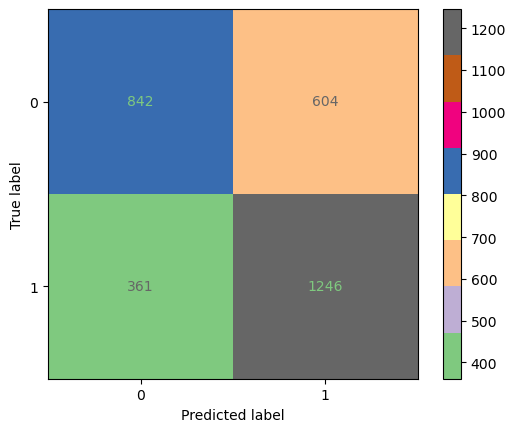

In [314]:
# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm,

display_labels=rf1.classes_,
)
disp.plot(cmap='Accent', values_format='');

**Remarque :** Le modèle a presque deux fois plus de chances de prédire un faux positif qu'un faux négatif. Par conséquent, les erreurs de type I sont plus fréquentes. Ceci est moins souhaitable, car il est préférable pour un conducteur d'être agréablement surpris par un pourboire généreux auquel il ne s'attendait pas, plutôt que d'être déçu par un pourboire insuffisant alors qu'il s'attendait à un pourboire important.

****`Toutfois, les performances globales de ce modèle sont satisfaisantes.`****

#### Importance des caractéristiques
A present l'on va utiliser l'attribut `feature_importances_` de l'objet « best_estimator » pour examiner les caractéristiques du modèle final. 

Ensuite l'on pourra les trier et représenter graphiquement les plus importantes.

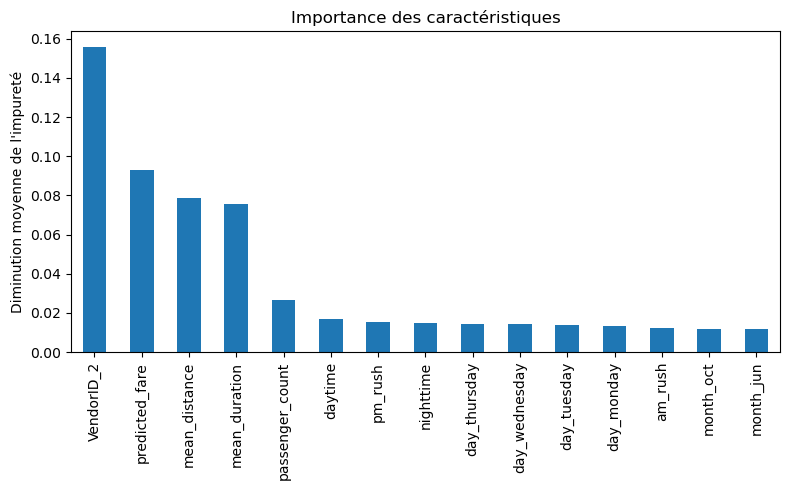

In [317]:
importances = rf1.best_estimator_.feature_importances_
rf_importances = pd.Series(importances, index=X_test.columns)
rf_importances = rf_importances.sort_values(ascending=False)[:15]

fig, ax = plt.subplots(figsize=(8,5))
rf_importances.plot.bar(ax=ax)
ax.set_title('Importance des caractéristiques')
ax.set_ylabel("Diminution moyenne de l'impureté")

fig.tight_layout()

### **4. Conclusion**

Dans cette étape, utilisez les résultats des modèles précédents pour formuler une conclusion. Répondez aux questions suivantes :

**Exemples de réponses :**

1. **Recommanderiez-vous l’utilisation de ce modèle ? Pourquoi ?**

Oui, ce modèle est performant. Son score F1 était de 0,7235 et sa précision globale de 0,6865. Il a correctement identifié environ 78 % des répondants dans l’ensemble de test, soit 48 % de mieux qu’une réponse aléatoire. Il pourrait être judicieux de tester le modèle auprès d’un groupe restreint de chauffeurs de taxi afin d’obtenir des retours.

2. **Quel était le fonctionnement de votre modèle le plus performant ? Pouvez-vous expliquer comment il effectuait ses prédictions ?**

Malheureusement, la forêt aléatoire n’est pas l’algorithme d’apprentissage automatique le plus transparent. Nous savons que `VendorID`, `predicted_fare`, `mean_duration` et `mean_distance` sont les variables les plus importantes, mais nous ignorons leur influence sur les pourboires. Des recherches supplémentaires sont nécessaires. Il est intéressant de noter que `VendorID` est la variable la plus prédictive. Cela semble indiquer que l'un des deux vendeurs attire une clientèle plus généreuse. Il serait judicieux de réaliser des tests statistiques sur les différents vendeurs afin d'approfondir cette question.

3. **Existe-t-il de nouvelles variables que vous pourriez concevoir pour améliorer les performances du modèle ?**

Il est presque toujours possible de concevoir des variables supplémentaires, mais idéalement, les plus évidentes ont été générées lors de la première phase de modélisation. Dans notre cas, nous pourrions créer trois nouvelles colonnes indiquant si la distance du trajet est courte, moyenne ou longue. Nous pourrions également concevoir une colonne calculant un ratio : (montant du prix de la course arrondi au multiple de 5 dollras supérieur) / prix de la course. Par exemple, si le prix du billet est de 12 dollars, la valeur dans cette colonne sera de 0,25, car 12 dollars arrondi à la tranche supérieure de 5 dollars la plus proche (15 dollars) équivaut à 3 dollars, et 3 dollars divisé par 12dollars donne 0,25. L'idée derrière cette fonctionnalité est que les gens ont tendance à arrondir leur pourboire à l'euro supérieur. Ainsi, les trajets dont le prix est légèrement inférieur à un multiple de 5 dollars pourraient avoir des pourcentages de pourboire plus faibles que ceux dont le prix est légèrement supérieur à un multiple de 5 $. On pourrait également appliquer le même principe aux tarifs arrondis à la dizaine de dollars la plus proche.

$$
round5_{ratio} = \frac{montant \ d'argent \ du \ prix \ de\ la\ course\ au\ multiple\ supérieur\ le\ plus \ proche \ de \ 5 \ dollars}{prix \ de \ la \ course}
$$

4. **Quelles fonctionnalités souhaiteriez-vous ajouter pour améliorer les performances de votre modèle ?**

Il serait probablement très utile de disposer de l'historique des pourboires de chaque client. Il serait également précieux de connaître la valeur exacte des pourboires pour les clients payant en espèces.
Il serait utile de disposer de davantage de données. Avec suffisamment de données, nous pourrions créer une caractéristique unique pour chaque combinaison de prise en charge/dépose.

Retenir que, parfois, les données disponibles ne seront tout simplement pas prédictives de votre cible. C'est fréquent. L'apprentissage automatique est un outil puissant, mais il n'est pas magique. Si ces données ne contiennent pas de signal prédictif, même l'algorithme le plus complexe ne pourra pas fournir de prédictions cohérentes et précises. Tirer toujours cette conclusion. Même si vous ne pouvez pas utiliser le modèle pour faire des prédictions fiables, le travail accompli aura-t-il été vain ? Quelles informations pouvez-vous partager avec les parties prenantes ?

**Félicitations !** 